In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pymc as pm
import pytensor.tensor as pt
import pytensor
import arviz_plots as azp
import arviz as az
import statsmodels.api as sm

In [2]:
lynx_data = sm.datasets.get_rdataset("lynx", "datasets").data
print(lynx_data.shape)
lynx_data.head()

(114, 2)


,time,value
0,1821,269
1,1822,321
2,1823,585
3,1824,871
4,1825,1475


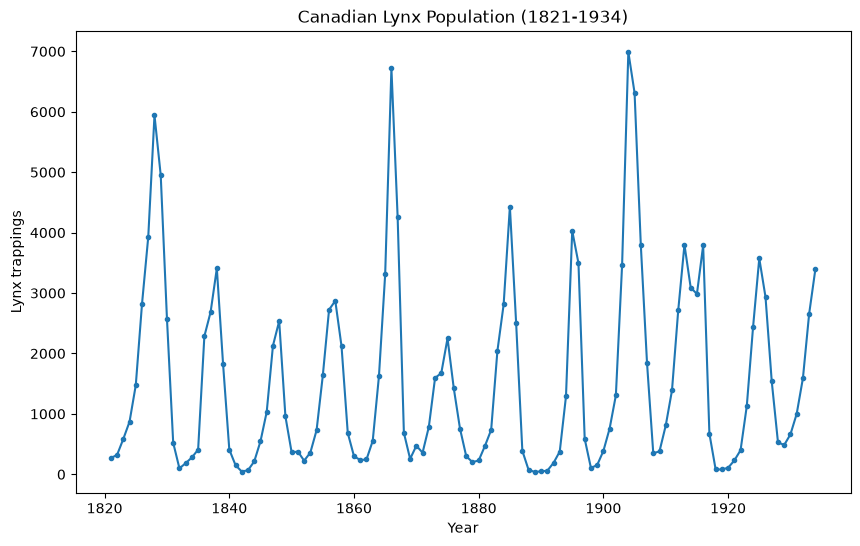

In [3]:
count = lynx_data["value"].values
log_count = np.log(count)
n = len(count)
years = np.arange(1821, 1821 + n)

plt.figure(figsize=(10, 6))
plt.plot(years, count, marker="o", markersize=3)
plt.xlabel('Year')
plt.ylabel('Lynx trappings')
plt.title('Canadian Lynx Population (1821-1934)')
plt.show()


In [4]:
with pm.Model() as model_lynx:
    r = pm.Normal('r', mu=0.5, sigma=0.5)
    K = pm.Normal('K', mu=log_count.mean(), sigma=2)
    sigma_process = pm.HalfNormal("sigma_process", sigma=0.5)
    sigma_obs = pm.HalfNormal("sigma_obs", sigma=0.5)

    x0 = pm.Normal("x0", mu=log_count[0], sigma=1)

    def transition(x_prev, r, K, sigma_process):
        mu_x = x_prev + r * (1 - pm.math.exp(x_prev) / K )
        return mu_x

    innovations = pm.Normal("innovations", mu=0, sigma=1, shape=n-1)

    def step(innov, x_prev, r, K, sigma_process):
        mu_x = x_prev + r * (1 - pm.math.exp(x_prev) / K)
        return mu_x + sigma_process * innov

    x_states, _ = pytensor.scan(
        fn=step,
        sequences=[innovations],
        outputs_info=[x0],
        non_sequences=[r, K, sigma_process]
    )

    x_full = pt.concatenate([[x0], x_states])

    obs = pm.Normal("obs", mu=x_full, sigma=sigma_obs, observed=log_count)

    trace_lynx = pm.sample(2000, tune=1500, chains=4, target_accept=0.9, random_seed=42)
           
        

/tmp/ipykernel_20668/642091137.py:19: DeprecationWarning: Scan return signature will change. Updates dict will not be returned, only the first argument. Pass `return_updates=False` to conform to the new API and avoid this warning
  x_states, _ = pytensor.scan(
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [r, K, sigma_process, sigma_obs, x0, innovations]


/home/manaty/markov-regime-switching/.venv/lib/python3.12/site-packages/rich/live.py:260: UserWarning: install 
"ipywidgets" for Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

/home/manaty/markov-regime-switching/.venv/lib/python3.12/site-packages/pymc/step_methods/hmc/quadpotential.py:321: RuntimeWarning: overflow encountered in dot
  return 0.5 * np.dot(x, v_out)
/home/manaty/markov-regime-switching/.venv/lib/python3.12/site-packages/pymc/step_methods/hmc/quadpotential.py:321: RuntimeWarning: overflow encountered in dot
  return 0.5 * np.dot(x, v_out)


Sampling 4 chains for 1_500 tune and 2_000 draw iterations (6_000 + 8_000 draws total) took 273 seconds.
There were 1440 divergences after tuning. Increase `target_accept` or reparameterize.
The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details
The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details


In [5]:
az.summary(trace_lynx, var_names=["r","K","sigma_process","sigma_obs","x0"])

,mean,sd,eti89_lb,eti89_ub,ess_bulk,ess_tail,r_hat,mcse_mean,mcse_sd
r,0.00061,0.00028,0.00017,0.0011,89,51,1.05,2.7e-05,2e-05
K,7.4,1.9,4.4,10,184,47,1.02,0.14,0.09
sigma_process,0.808,0.052,0.73,0.9,215,217,1.01,0.0036,0.0027
sigma_obs,0.08,0.04,0.022,0.15,40,42,1.08,0.0057,0.0055
x0,5.61,0.09,5.5,5.8,143,43,1.06,0.0087,0.0095


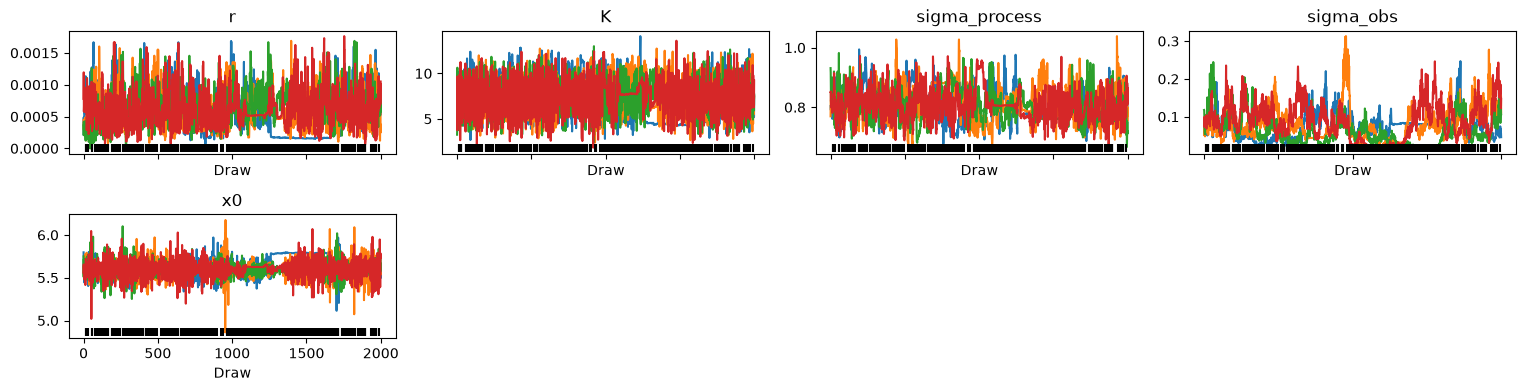

In [6]:
az.plot_trace(trace_lynx, var_names=["r","K","sigma_process","sigma_obs","x0"])
plt.tight_layout()
plt.show()

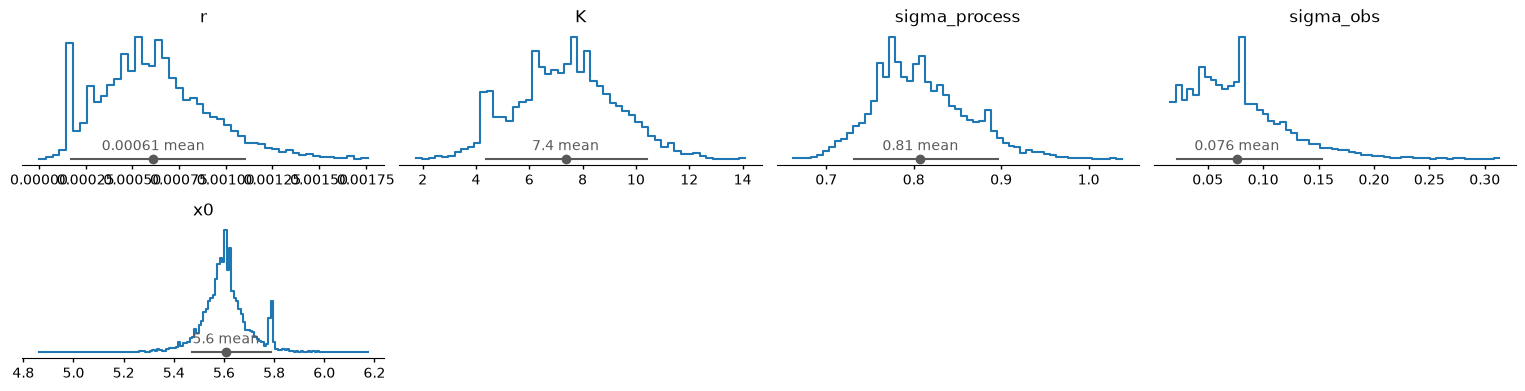

In [7]:
azp.plot_dist(trace_lynx, kind="hist", var_names=["r","K","sigma_process","sigma_obs","x0"])
plt.tight_layout()
plt.show()

In [8]:
n_divergent_lynx = trace_lynx.sample_stats.diverging.sum().item()
print(f"Divergences: {n_divergent_lynx}")

Divergences: 1440


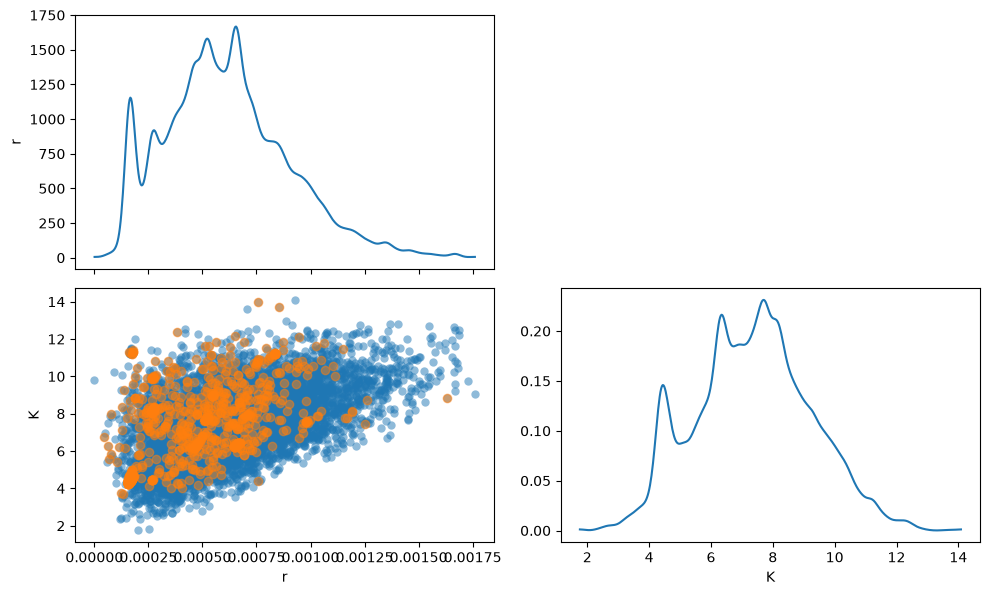

In [9]:
az.plot_pair(trace_lynx, var_names=["r", "K"], visuals={"divergence":True}, figure_kwargs={"figsize": (10, 6)})
plt.tight_layout()
plt.show()

In [10]:
count_mean = count.mean()
count_sd = count.std()
with pm.Model() as model_lynx:
    r = pm.Normal('r', mu=0.5, sigma=0.5)
    K = pm.Normal('K', mu=count_mean, sigma=count_sd * 2)
    sigma_process = pm.HalfNormal("sigma_process", sigma=0.5)
    sigma_obs = pm.HalfNormal("sigma_obs", sigma=0.5)

    x0 = pm.Normal("x0", mu=log_count[0], sigma=1)

    innovations = pm.Normal("innovations", mu=0, sigma=1, shape=n-1)

    def step(innov, x_prev, r, K, sigma_process):
        mu_x = x_prev + r * (1 - pm.math.exp(x_prev) / K)
        return mu_x + sigma_process * innov

    x_states, _ = pytensor.scan(
        fn=step,
        sequences=[innovations],
        outputs_info=[x0],
        non_sequences=[r, K, sigma_process]
    )

    x_full = pt.concatenate([[x0], x_states])

    obs = pm.Normal("obs", mu=x_full, sigma=sigma_obs, observed=log_count)

    trace_lynx = pm.sample(2000, tune=1500, chains=4, target_accept=0.9, random_seed=42)
           
        

/tmp/ipykernel_20668/1415389367.py:17: DeprecationWarning: Scan return signature will change. Updates dict will not be returned, only the first argument. Pass `return_updates=False` to conform to the new API and avoid this warning
  x_states, _ = pytensor.scan(
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [r, K, sigma_process, sigma_obs, x0, innovations]


/home/manaty/markov-regime-switching/.venv/lib/python3.12/site-packages/rich/live.py:260: UserWarning: install 
"ipywidgets" for Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

Sampling 4 chains for 1_500 tune and 2_000 draw iterations (6_000 + 8_000 draws total) took 303 seconds.
There were 178 divergences after tuning. Increase `target_accept` or reparameterize.
Chain 2 reached the maximum tree depth. Increase `max_treedepth`, increase `target_accept` or reparameterize.
Chain 3 reached the maximum tree depth. Increase `max_treedepth`, increase `target_accept` or reparameterize.
The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details
The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details


In [11]:
az.summary(trace_lynx, var_names=["r","K","sigma_process","sigma_obs","x0"])

,mean,sd,eti89_lb,eti89_ub,ess_bulk,ess_tail,r_hat,mcse_mean,mcse_sd
r,0.26,0.1,0.11,0.42,52,272,1.07,0.013,0.0087
K,2e+03,7e+02,1100,3100,153,167,1.04,58,74
sigma_process,0.797,0.054,0.72,0.89,266,388,1.01,0.0033,0.0023
sigma_obs,0.07,0.04,0.013,0.16,15,21,1.22,0.01,0.009
x0,5.599,0.081,5.5,5.7,1793,146,1.07,0.0019,0.0025


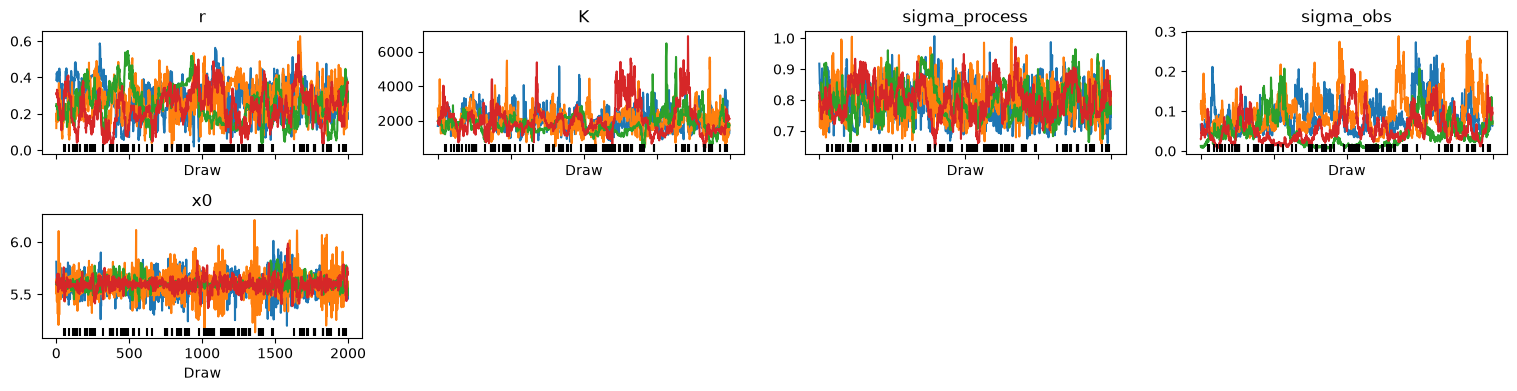

In [12]:
az.plot_trace(trace_lynx, var_names=["r","K","sigma_process","sigma_obs","x0"])
plt.tight_layout()
plt.show()

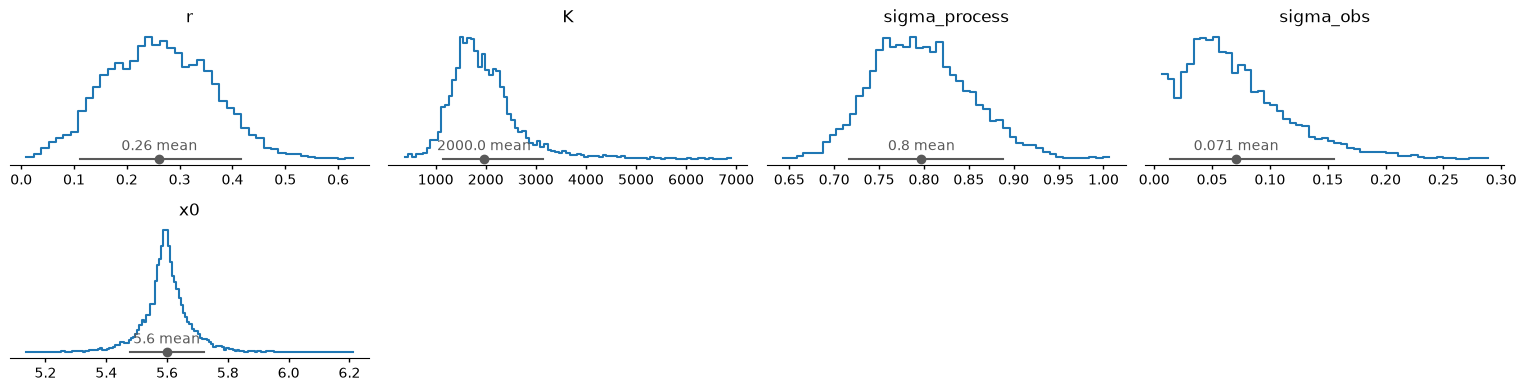

In [13]:
azp.plot_dist(trace_lynx, kind="hist", var_names=["r","K","sigma_process","sigma_obs","x0"])
plt.tight_layout()
plt.show()

In [14]:
n_divergent_lynx = trace_lynx.sample_stats.diverging.sum().item()
print(f"Divergences: {n_divergent_lynx}")

Divergences: 178


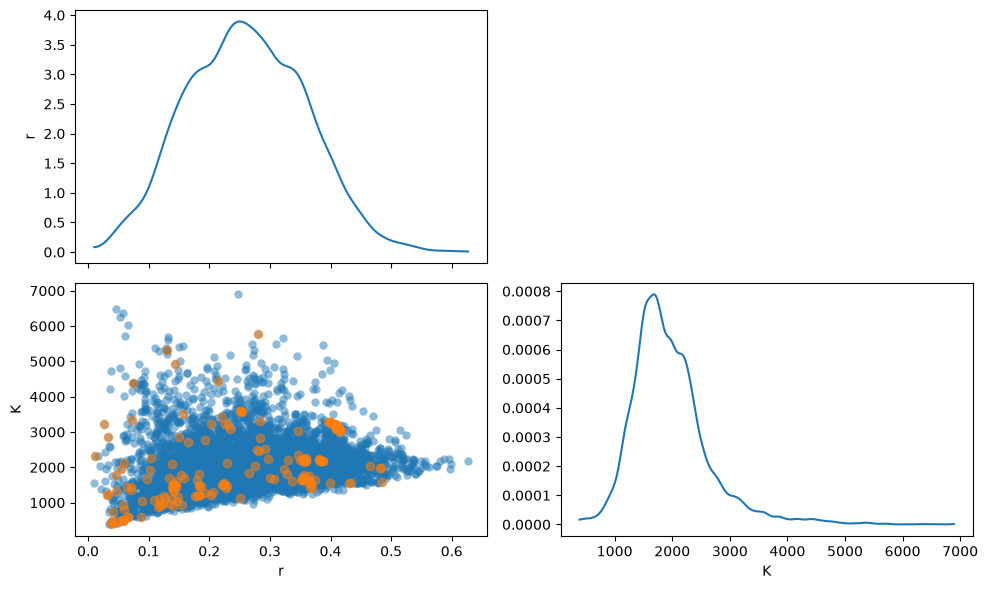

In [15]:
az.plot_pair(trace_lynx, var_names=["r", "K"], visuals={"divergence":True}, figure_kwargs={"figsize": (10, 6)})
plt.tight_layout()
plt.show()

In [16]:
count_mean = count.mean()
count_sd = count.std()
with pm.Model() as model_lynx:
    r = pm.TruncatedNormal('r', mu=0.5, sigma=0.5, lower=0)
    K = pm.TruncatedNormal('K', mu=count_mean, sigma=count_sd * 2, lower=100)
    sigma_process = pm.HalfNormal("sigma_process", sigma=0.5)
    sigma_obs = pm.HalfNormal("sigma_obs", sigma=0.5)

    x0 = pm.Normal("x0", mu=log_count[0], sigma=1)

    innovations = pm.Normal("innovations", mu=0, sigma=1, shape=n-1)

    def step(innov, x_prev, r, K, sigma_process):
        mu_x = x_prev + r * (1 - pm.math.exp(x_prev) / K)
        return mu_x + sigma_process * innov

    x_states, _ = pytensor.scan(
        fn=step,
        sequences=[innovations],
        outputs_info=[x0],
        non_sequences=[r, K, sigma_process]
    )

    x_full = pt.concatenate([[x0], x_states])

    obs = pm.Normal("obs", mu=x_full, sigma=sigma_obs, observed=log_count)

    trace_lynx = pm.sample(2000, tune=2000, chains=4, target_accept=0.95, random_seed=42)
           
        

/tmp/ipykernel_20668/1977752364.py:17: DeprecationWarning: Scan return signature will change. Updates dict will not be returned, only the first argument. Pass `return_updates=False` to conform to the new API and avoid this warning
  x_states, _ = pytensor.scan(
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [r, K, sigma_process, sigma_obs, x0, innovations]


/home/manaty/markov-regime-switching/.venv/lib/python3.12/site-packages/rich/live.py:260: UserWarning: install 
"ipywidgets" for Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

Sampling 4 chains for 2_000 tune and 2_000 draw iterations (8_000 + 8_000 draws total) took 339 seconds.
There were 143 divergences after tuning. Increase `target_accept` or reparameterize.
Chain 2 reached the maximum tree depth. Increase `max_treedepth`, increase `target_accept` or reparameterize.
The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details
The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details


In [17]:
az.summary(trace_lynx, var_names=["r","K","sigma_process","sigma_obs","x0"])

,mean,sd,eti89_lb,eti89_ub,ess_bulk,ess_tail,r_hat,mcse_mean,mcse_sd
r,0.27,0.098,0.11,0.43,300,451,1.02,0.0056,0.0039
K,2e+03,6e+02,1100,3000,408,640,1.01,29,39
sigma_process,0.796,0.052,0.72,0.88,510,717,1.01,0.0023,0.0017
sigma_obs,0.09,0.05,0.027,0.17,48,29,1.09,0.0057,0.0057
x0,5.596,0.095,5.5,5.7,7090,1052,1.02,0.0011,0.0014


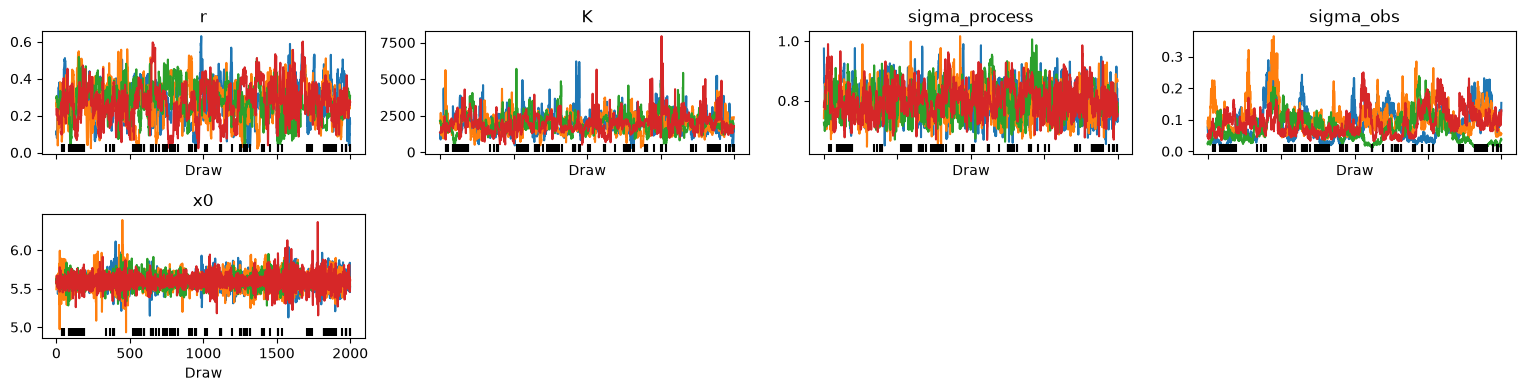

In [18]:
az.plot_trace(trace_lynx, var_names=["r","K","sigma_process","sigma_obs","x0"])
plt.tight_layout()
plt.show()

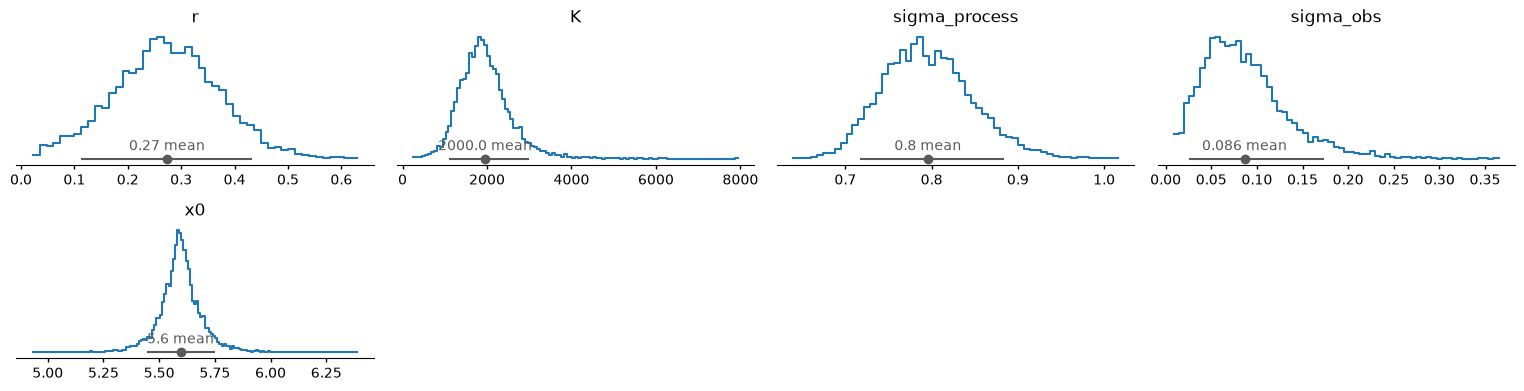

In [19]:
azp.plot_dist(trace_lynx, kind="hist", var_names=["r","K","sigma_process","sigma_obs","x0"])
plt.tight_layout()
plt.show()

In [20]:
n_divergent_lynx = trace_lynx.sample_stats.diverging.sum().item()
print(f"Divergences: {n_divergent_lynx}")

Divergences: 143


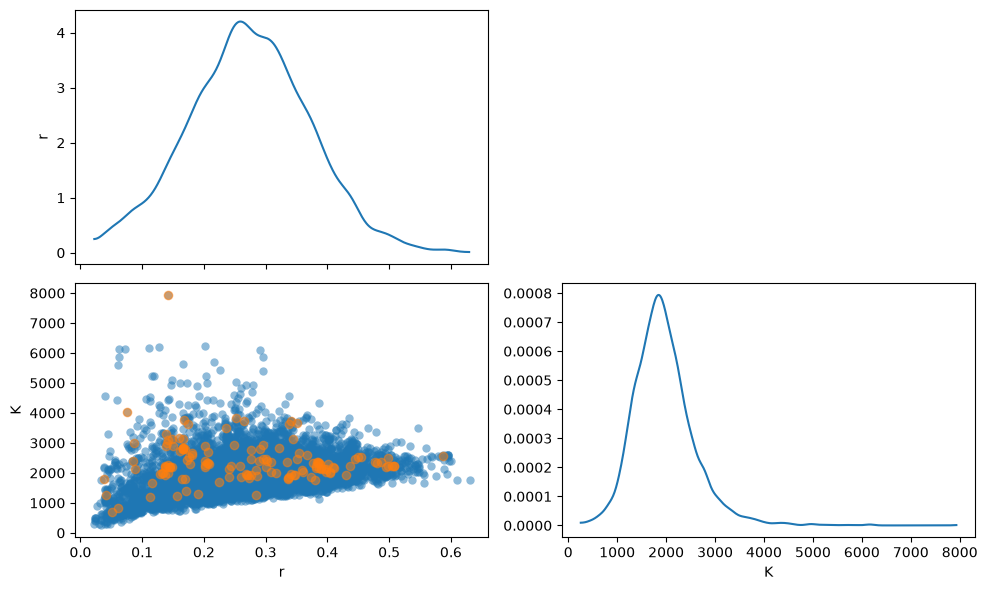

In [21]:
az.plot_pair(trace_lynx, var_names=["r", "K"], visuals={"divergence":True}, figure_kwargs={"figsize": (10, 6)})
plt.tight_layout()
plt.show()

In [22]:
with pm.Model() as model_lynx:
    r = pm.TruncatedNormal('r', mu=0.5, sigma=0.5, lower=0)
    
    log_K = pm.Normal('log_K', mu=np.log(count_mean), sigma=0.5)
    K = pm.Deterministic('K', pm.math.exp(log_K))
    
    sigma_process = pm.HalfNormal("sigma_process", sigma=0.5)
    sigma_obs = pm.HalfNormal("sigma_obs", sigma=0.5)
    x0 = pm.Normal("x0", mu=log_count[0], sigma=1)
    innovations = pm.Normal("innovations", mu=0, sigma=1, shape=n-1)

    def step(innov, x_prev, r, K, sigma_process):
        mu_x = x_prev + r * (1 - pm.math.exp(x_prev) / K)
        return mu_x + sigma_process * innov

    x_states, _ = pytensor.scan(
        fn=step,
        sequences=[innovations],
        outputs_info=[x0],
        non_sequences=[r, K, sigma_process]
    )

    x_full = pt.concatenate([[x0], x_states])

    obs = pm.Normal("obs", mu=x_full, sigma=sigma_obs, observed=log_count)

    trace_lynx = pm.sample(2000, tune=2000, chains=4, target_accept=0.95, random_seed=42)
           
        

/tmp/ipykernel_20668/1193693001.py:16: DeprecationWarning: Scan return signature will change. Updates dict will not be returned, only the first argument. Pass `return_updates=False` to conform to the new API and avoid this warning
  x_states, _ = pytensor.scan(
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [r, log_K, sigma_process, sigma_obs, x0, innovations]


/home/manaty/markov-regime-switching/.venv/lib/python3.12/site-packages/rich/live.py:260: UserWarning: install 
"ipywidgets" for Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

Sampling 4 chains for 2_000 tune and 2_000 draw iterations (8_000 + 8_000 draws total) took 187 seconds.
There were 155 divergences after tuning. Increase `target_accept` or reparameterize.
The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details
The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details


In [23]:
az.summary(trace_lynx, var_names=["r","K","sigma_process","sigma_obs","x0"])

,mean,sd,eti89_lb,eti89_ub,ess_bulk,ess_tail,r_hat,mcse_mean,mcse_sd
r,0.27,0.091,0.13,0.42,315,396,1.01,0.0051,0.0036
K,2e+03,4e+02,1100,2400,311,657,1.01,23,19
sigma_process,0.792,0.05,0.72,0.87,581,818,1.00,0.0021,0.0015
sigma_obs,0.08,0.05,0.025,0.17,35,85,1.11,0.0067,0.0062
x0,5.595,0.089,5.5,5.7,6943,527,1.03,0.0011,0.0015


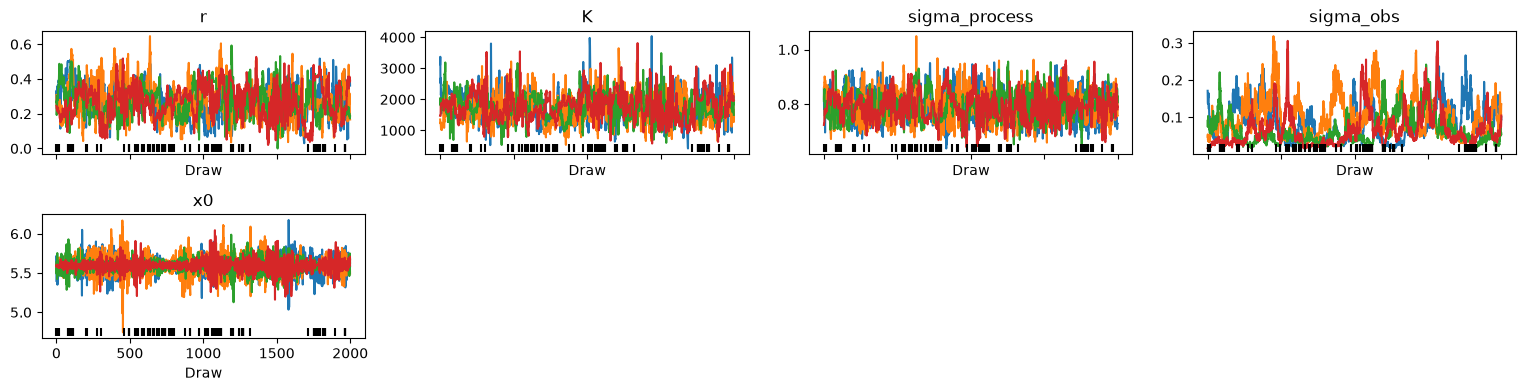

In [24]:
az.plot_trace(trace_lynx, var_names=["r","K","sigma_process","sigma_obs","x0"])
plt.tight_layout()
plt.show()

In [25]:
n_divergent_lynx = trace_lynx.sample_stats.diverging.sum().item()
print(f"Divergences: {n_divergent_lynx}")

Divergences: 155


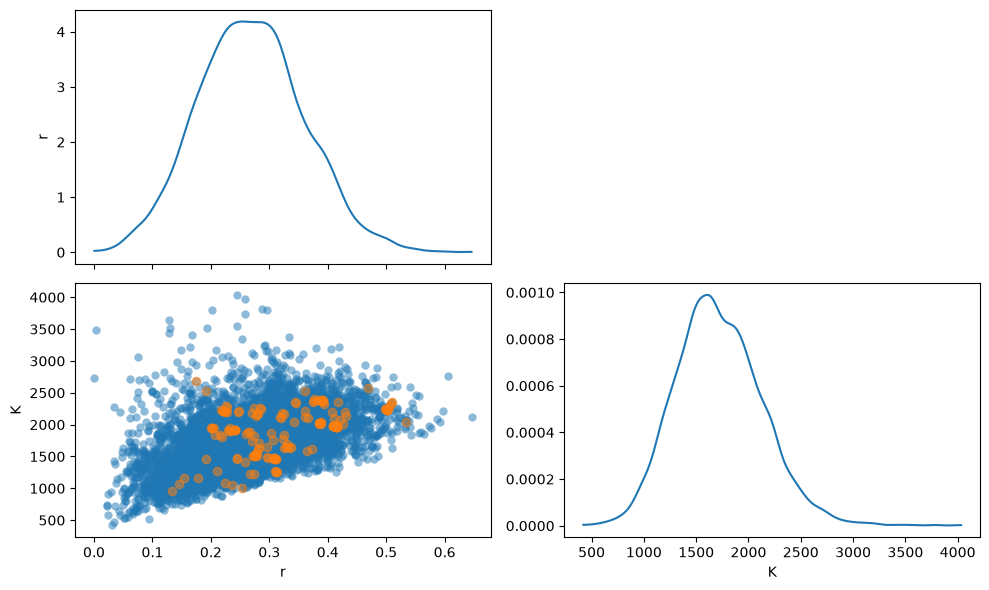

In [26]:
az.plot_pair(trace_lynx, var_names=["r", "K"], visuals={"divergence":True}, figure_kwargs={"figsize": (10, 6)})
plt.tight_layout()
plt.show()

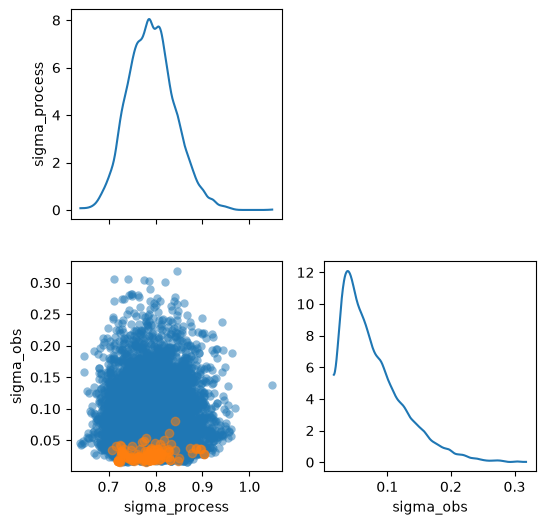

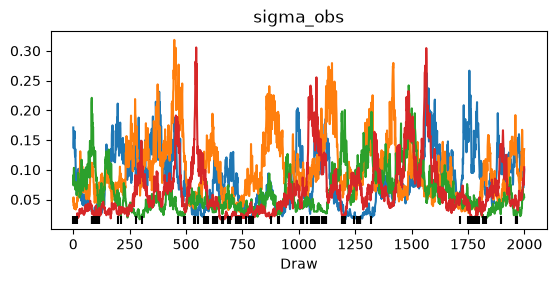

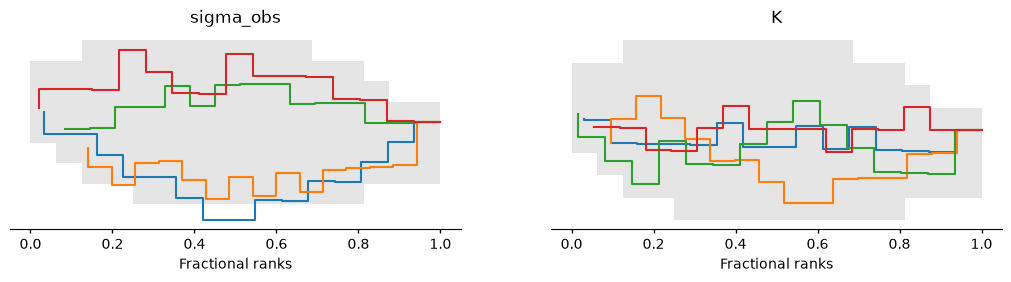

In [27]:
az.plot_pair(
    trace_lynx,
    var_names=["sigma_process", "sigma_obs"],
    visuals={"divergence": True},
    figure_kwargs={"figsize": (6, 6)}
)

az.plot_trace(trace_lynx, var_names=["sigma_obs"])
az.plot_rank(trace_lynx, var_names=["sigma_obs", "K"])

In [28]:
#sigma_obs が小さい値をとろうとするときに、サンプラーが不安定になり、チェーン間でも収束せず(r_hat=1.11)、そこでdivergenceが多発している


In [29]:
with pm.Model() as model_lynx:
    r = pm.TruncatedNormal('r', mu=0.5, sigma=0.5, lower=0)
    
    log_K = pm.Normal('log_K', mu=np.log(count_mean), sigma=0.5)
    K = pm.Deterministic('K', pm.math.exp(log_K))
    
    sigma_process = pm.HalfNormal("sigma_process", sigma=0.5)
    sigma_obs = pm.HalfNormal("sigma_obs", sigma=0.1)
    x0 = pm.Normal("x0", mu=log_count[0], sigma=1)
    innovations = pm.Normal("innovations", mu=0, sigma=1, shape=n-1)

    def step(innov, x_prev, r, K, sigma_process):
        mu_x = x_prev + r * (1 - pm.math.exp(x_prev) / K)
        return mu_x + sigma_process * innov

    x_states, _ = pytensor.scan(
        fn=step,
        sequences=[innovations],
        outputs_info=[x0],
        non_sequences=[r, K, sigma_process]
    )

    x_full = pt.concatenate([[x0], x_states])

    obs = pm.Normal("obs", mu=x_full, sigma=sigma_obs, observed=log_count)

    trace_lynx = pm.sample(2000, tune=2000, chains=4, target_accept=0.95, random_seed=42)
           
        

/tmp/ipykernel_20668/4285443124.py:16: DeprecationWarning: Scan return signature will change. Updates dict will not be returned, only the first argument. Pass `return_updates=False` to conform to the new API and avoid this warning
  x_states, _ = pytensor.scan(
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [r, log_K, sigma_process, sigma_obs, x0, innovations]


/home/manaty/markov-regime-switching/.venv/lib/python3.12/site-packages/rich/live.py:260: UserWarning: install 
"ipywidgets" for Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

/home/manaty/markov-regime-switching/.venv/lib/python3.12/site-packages/pymc/step_methods/hmc/quadpotential.py:321: RuntimeWarning: overflow encountered in dot
  return 0.5 * np.dot(x, v_out)
/home/manaty/markov-regime-switching/.venv/lib/python3.12/site-packages/pymc/step_methods/hmc/quadpotential.py:321: RuntimeWarning: overflow encountered in dot
  return 0.5 * np.dot(x, v_out)
/home/manaty/markov-regime-switching/.venv/lib/python3.12/site-packages/pymc/step_methods/hmc/quadpotential.py:321: RuntimeWarning: overflow encountered in dot
  return 0.5 * np.dot(x, v_out)


Sampling 4 chains for 2_000 tune and 2_000 draw iterations (8_000 + 8_000 draws total) took 218 seconds.
There were 247 divergences after tuning. Increase `target_accept` or reparameterize.
The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details
The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details


In [30]:
az.summary(trace_lynx, var_names=["r","K","sigma_process","sigma_obs","x0"])

,mean,sd,eti89_lb,eti89_ub,ess_bulk,ess_tail,r_hat,mcse_mean,mcse_sd
r,0.25,0.09,0.11,0.42,195,211,1.02,0.007,0.005
K,2e+03,4e+02,1000,2400,310,502,1.00,24,23
sigma_process,0.789,0.054,0.71,0.88,420,609,1.02,0.0026,0.0018
sigma_obs,0.07,0.03,0.021,0.13,17,55,1.18,0.0075,0.0058
x0,5.594,0.073,5.5,5.7,7546,1235,1.03,0.00085,0.00098


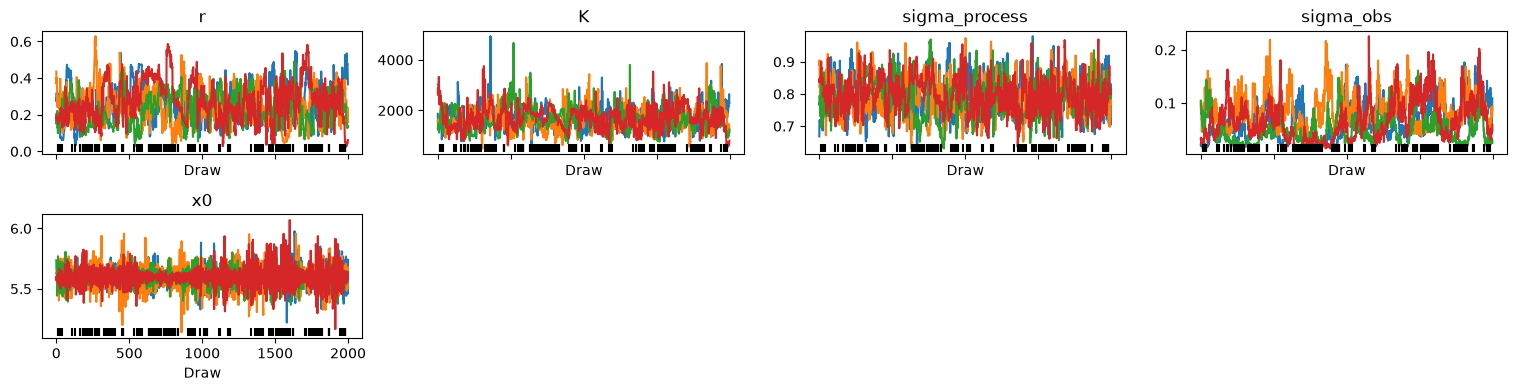

In [31]:
az.plot_trace(trace_lynx, var_names=["r","K","sigma_process","sigma_obs","x0"])
plt.tight_layout()
plt.show()

In [32]:
n_divergent_lynx = trace_lynx.sample_stats.diverging.sum().item()
print(f"Divergences: {n_divergent_lynx}")

Divergences: 247


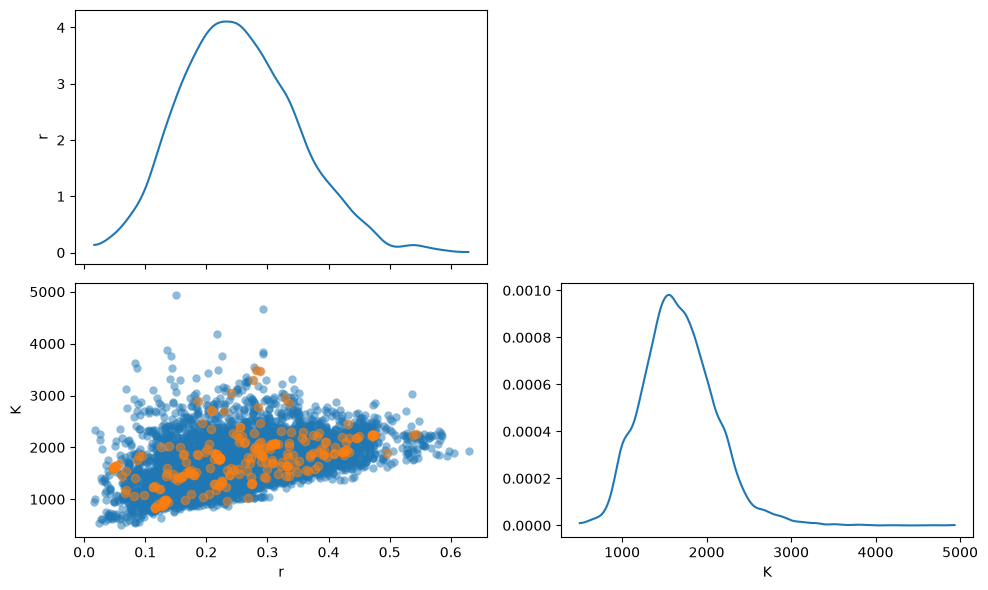

In [33]:
az.plot_pair(trace_lynx, var_names=["r", "K"], visuals={"divergence":True}, figure_kwargs={"figsize": (10, 6)})
plt.tight_layout()
plt.show()

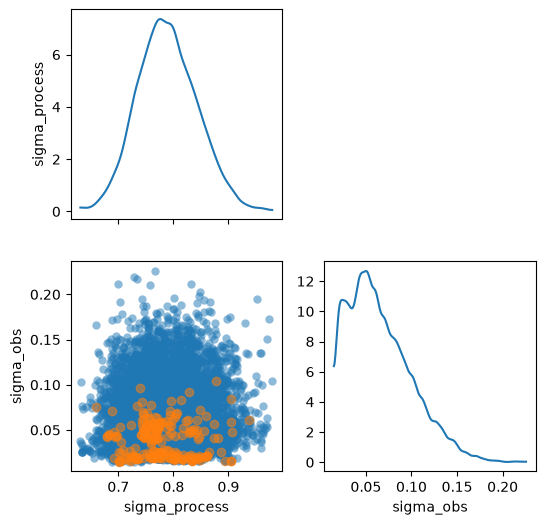

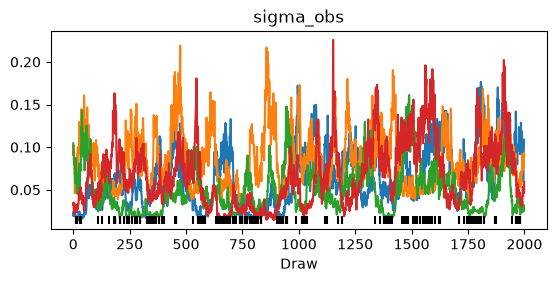

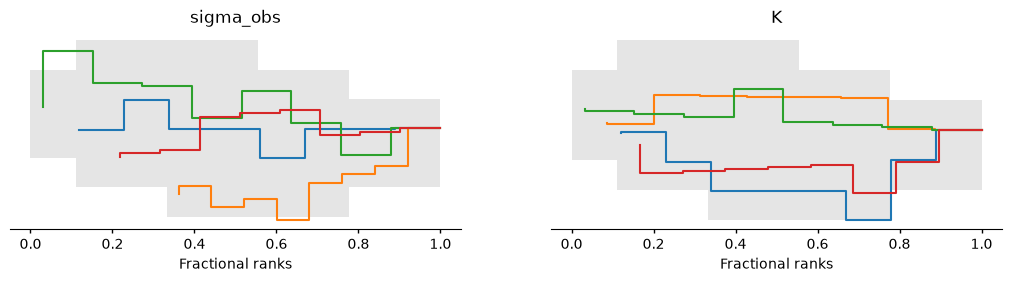

In [34]:
az.plot_pair(
    trace_lynx,
    var_names=["sigma_process", "sigma_obs"],
    visuals={"divergence": True},
    figure_kwargs={"figsize": (6, 6)}
)

az.plot_trace(trace_lynx, var_names=["sigma_obs"])
az.plot_rank(trace_lynx, var_names=["sigma_obs", "K"])

In [35]:
#サンプラー強化
with pm.Model() as model_lynx:
    r = pm.TruncatedNormal('r', mu=0.5, sigma=0.5, lower=0)
    
    log_K = pm.Normal('log_K', mu=np.log(count_mean), sigma=0.5)
    K = pm.Deterministic('K', pm.math.exp(log_K))
    
    sigma_process = pm.HalfNormal("sigma_process", sigma=0.5)
    sigma_obs = pm.HalfNormal("sigma_obs", sigma=0.1)
    x0 = pm.Normal("x0", mu=log_count[0], sigma=1)
    innovations = pm.Normal("innovations", mu=0, sigma=1, shape=n-1)

    def step(innov, x_prev, r, K, sigma_process):
        mu_x = x_prev + r * (1 - pm.math.exp(x_prev) / K)
        return mu_x + sigma_process * innov

    x_states, _ = pytensor.scan(
        fn=step,
        sequences=[innovations],
        outputs_info=[x0],
        non_sequences=[r, K, sigma_process]
    )

    x_full = pt.concatenate([[x0], x_states])

    obs = pm.Normal("obs", mu=x_full, sigma=sigma_obs, observed=log_count)

    trace_lynx = pm.sample(
    2000, tune=3000, chains=4,
    target_accept=0.99,
    init="jitter+adapt_diag_grad",
    random_seed=42
)
           
        

/tmp/ipykernel_20668/3305106006.py:17: DeprecationWarning: Scan return signature will change. Updates dict will not be returned, only the first argument. Pass `return_updates=False` to conform to the new API and avoid this warning
  x_states, _ = pytensor.scan(
Initializing NUTS using jitter+adapt_diag_grad...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [r, log_K, sigma_process, sigma_obs, x0, innovations]


/home/manaty/markov-regime-switching/.venv/lib/python3.12/site-packages/rich/live.py:260: UserWarning: install 
"ipywidgets" for Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

/home/manaty/markov-regime-switching/.venv/lib/python3.12/site-packages/pymc/step_methods/hmc/quadpotential.py:321: RuntimeWarning: overflow encountered in dot
  return 0.5 * np.dot(x, v_out)
/home/manaty/markov-regime-switching/.venv/lib/python3.12/site-packages/pymc/step_methods/hmc/quadpotential.py:321: RuntimeWarning: overflow encountered in dot
  return 0.5 * np.dot(x, v_out)
/home/manaty/markov-regime-switching/.venv/lib/python3.12/site-packages/pymc/step_methods/hmc/quadpotential.py:321: RuntimeWarning: overflow encountered in dot
  return 0.5 * np.dot(x, v_out)


Sampling 4 chains for 3_000 tune and 2_000 draw iterations (12_000 + 8_000 draws total) took 395 seconds.
There were 34 divergences after tuning. Increase `target_accept` or reparameterize.
Chain 2 reached the maximum tree depth. Increase `max_treedepth`, increase `target_accept` or reparameterize.
The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details
The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details


In [36]:
az.summary(trace_lynx, var_names=["r","K","sigma_process","sigma_obs","x0"])

,mean,sd,eti89_lb,eti89_ub,ess_bulk,ess_tail,r_hat,mcse_mean,mcse_sd
r,0.26,0.086,0.13,0.41,187,252,1.04,0.0063,0.0045
K,2e+03,5e+02,1100,2700,27,27,1.12,96,95
sigma_process,0.788,0.051,0.71,0.88,172,283,1.02,0.0038,0.0029
sigma_obs,0.06,0.04,0.0091,0.12,16,29,1.20,0.0085,0.006
x0,5.592,0.067,5.5,5.7,2637,243,1.07,0.0014,0.0017


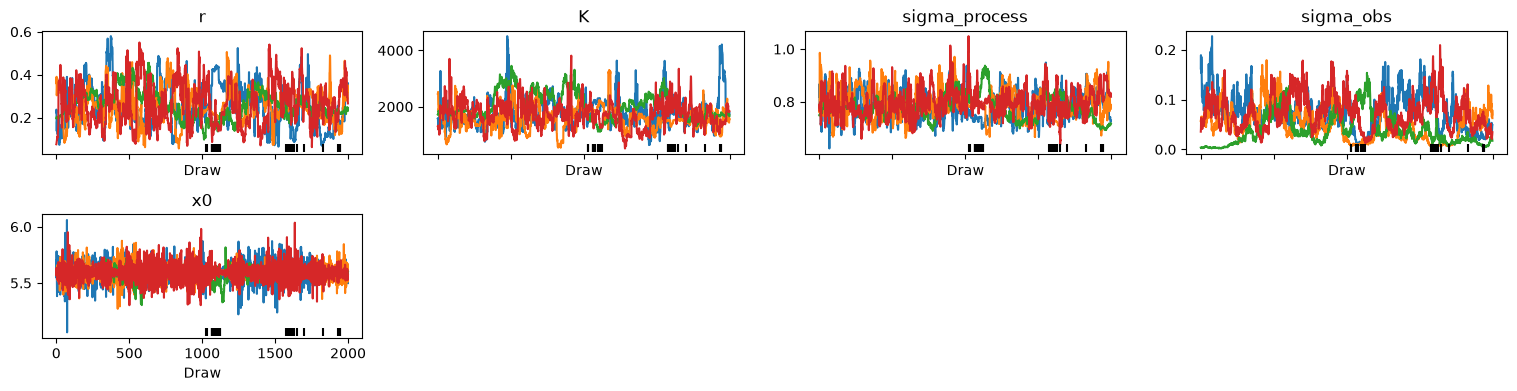

In [37]:
az.plot_trace(trace_lynx, var_names=["r","K","sigma_process","sigma_obs","x0"])
plt.tight_layout()
plt.show()

In [38]:
n_divergent_lynx = trace_lynx.sample_stats.diverging.sum().item()
print(f"Divergences: {n_divergent_lynx}")

Divergences: 34


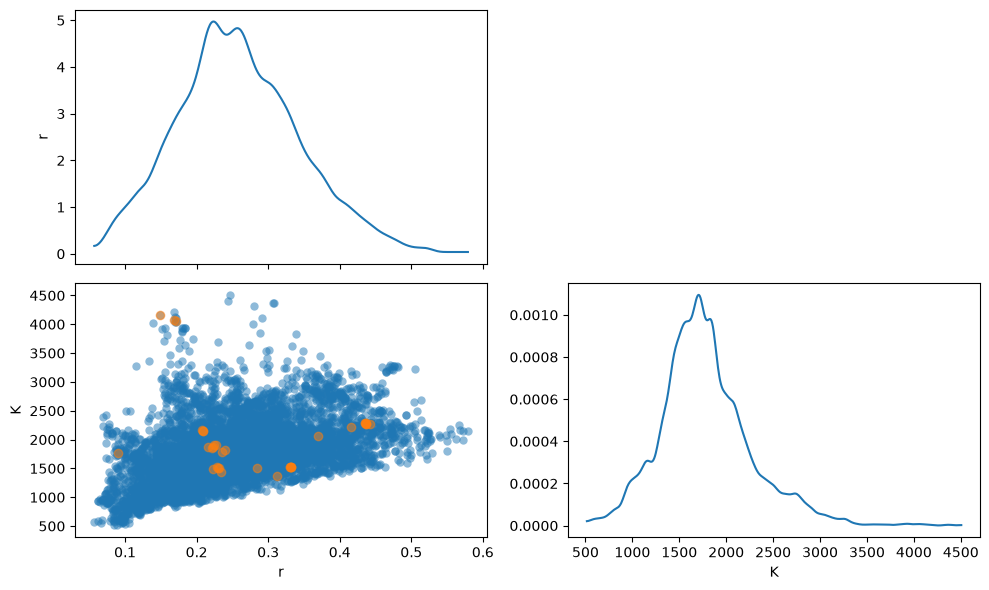

In [39]:
az.plot_pair(trace_lynx, var_names=["r", "K"], visuals={"divergence":True}, figure_kwargs={"figsize": (10, 6)})
plt.tight_layout()
plt.show()

In [40]:
#サンプラー強化
with pm.Model() as model_lynx_v2:
    r = pm.TruncatedNormal('r', mu=0.5, sigma=0.5, lower=0)
    
    log_K = pm.Normal('log_K', mu=np.log(count_mean), sigma=0.5)
    K = pm.Deterministic('K', pm.math.exp(log_K))
    
    sigma_process = pm.HalfNormal("sigma_process", sigma=0.5)
    sigma_obs = pm.HalfNormal("sigma_obs", sigma=0.5)  # 元の緩い事前分布に戻す
    x0 = pm.Normal("x0", mu=log_count[0], sigma=1)
    innovations = pm.Normal("innovations", mu=0, sigma=1, shape=n-1)

    def step(innov, x_prev, r, K, sigma_process):
        mu_x = x_prev + r * (1 - pm.math.exp(x_prev) / K)
        return mu_x + sigma_process * innov

    x_states, _ = pytensor.scan(
        fn=step,
        sequences=[innovations],
        outputs_info=[x0],
        non_sequences=[r, K, sigma_process]
    )

    x_full = pt.concatenate([[x0], x_states])

    obs = pm.Normal("obs", mu=x_full, sigma=sigma_obs, observed=log_count)

    trace_v2 = pm.sample(
    2000, tune=2000, chains=4,
    target_accept=0.9,
    init="jitter+adapt_diag_grad",
    random_seed=42
)
           
        

/tmp/ipykernel_20668/970573234.py:17: DeprecationWarning: Scan return signature will change. Updates dict will not be returned, only the first argument. Pass `return_updates=False` to conform to the new API and avoid this warning
  x_states, _ = pytensor.scan(
Initializing NUTS using jitter+adapt_diag_grad...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [r, log_K, sigma_process, sigma_obs, x0, innovations]


/home/manaty/markov-regime-switching/.venv/lib/python3.12/site-packages/rich/live.py:260: UserWarning: install 
"ipywidgets" for Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

Sampling 4 chains for 2_000 tune and 2_000 draw iterations (8_000 + 8_000 draws total) took 82 seconds.
There were 775 divergences after tuning. Increase `target_accept` or reparameterize.
The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details
The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details


In [41]:
az.summary(trace_v2, var_names=["r","K","sigma_process","sigma_obs","x0"])

,mean,sd,eti89_lb,eti89_ub,ess_bulk,ess_tail,r_hat,mcse_mean,mcse_sd
r,0.27,0.093,0.13,0.42,242,178,1.03,0.0059,0.0041
K,2e+03,4e+02,1100,2400,230,363,1.01,27,25
sigma_process,0.788,0.052,0.71,0.87,449,681,1.02,0.0024,0.0019
sigma_obs,0.08,0.05,0.022,0.17,10,19,1.31,0.013,0.013
x0,5.596,0.093,5.5,5.7,8182,168,1.08,0.00097,0.0012


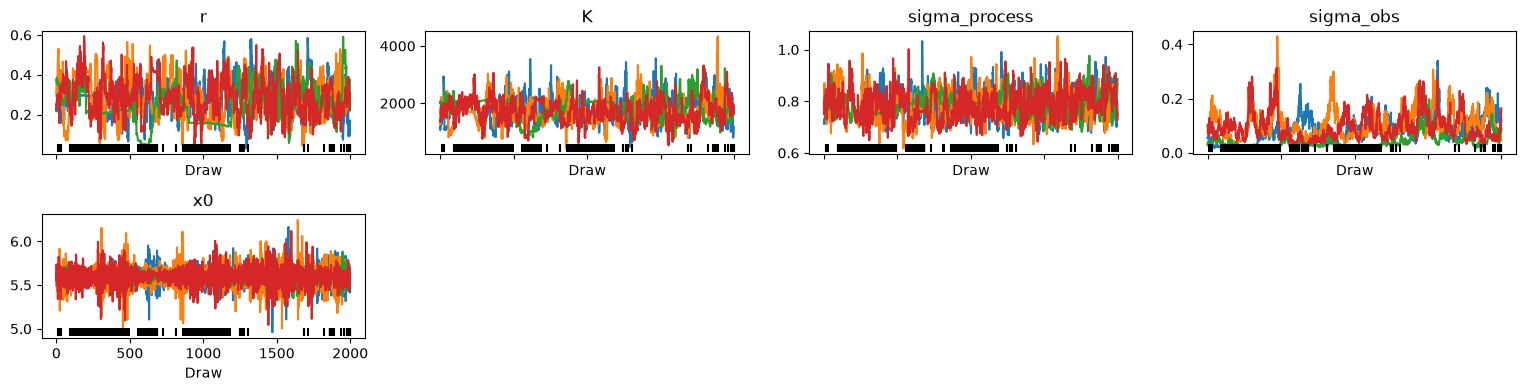

In [42]:
az.plot_trace(trace_v2, var_names=["r","K","sigma_process","sigma_obs","x0"])
plt.tight_layout()
plt.show()

In [43]:
n_divergent_lynx = trace_v2.sample_stats.diverging.sum().item()
print(f"Divergences: {n_divergent_lynx}")

Divergences: 775


In [44]:
#サンプラー強化
with pm.Model() as model_lynx_v2:
    r = pm.TruncatedNormal('r', mu=0.5, sigma=0.5, lower=0)
    
    log_K = pm.Normal('log_K', mu=np.log(count_mean), sigma=0.5)
    K = pm.Deterministic('K', pm.math.exp(log_K))
    
    sigma_process = pm.HalfNormal("sigma_process", sigma=0.5)
    sigma_obs = 0.05
    x0 = pm.Normal("x0", mu=log_count[0], sigma=1)
    innovations = pm.Normal("innovations", mu=0, sigma=1, shape=n-1)

    def step(innov, x_prev, r, K, sigma_process):
        mu_x = x_prev + r * (1 - pm.math.exp(x_prev) / K)
        return mu_x + sigma_process * innov

    x_states, _ = pytensor.scan(
        fn=step,
        sequences=[innovations],
        outputs_info=[x0],
        non_sequences=[r, K, sigma_process]
    )

    x_full = pt.concatenate([[x0], x_states])

    obs = pm.Normal("obs", mu=x_full, sigma=sigma_obs, observed=log_count)

    trace_v2 = pm.sample(
    2000, tune=2000, chains=4,
    target_accept=0.9,
    init="jitter+adapt_diag_grad",
    random_seed=42
)
           
        

/tmp/ipykernel_20668/1049278552.py:17: DeprecationWarning: Scan return signature will change. Updates dict will not be returned, only the first argument. Pass `return_updates=False` to conform to the new API and avoid this warning
  x_states, _ = pytensor.scan(
Initializing NUTS using jitter+adapt_diag_grad...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [r, log_K, sigma_process, x0, innovations]


/home/manaty/markov-regime-switching/.venv/lib/python3.12/site-packages/rich/live.py:260: UserWarning: install 
"ipywidgets" for Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

/home/manaty/markov-regime-switching/.venv/lib/python3.12/site-packages/pymc/step_methods/hmc/quadpotential.py:321: RuntimeWarning: overflow encountered in dot
  return 0.5 * np.dot(x, v_out)
/home/manaty/markov-regime-switching/.venv/lib/python3.12/site-packages/pymc/step_methods/hmc/quadpotential.py:321: RuntimeWarning: overflow encountered in dot
  return 0.5 * np.dot(x, v_out)


Sampling 4 chains for 2_000 tune and 2_000 draw iterations (8_000 + 8_000 draws total) took 48 seconds.
There were 14 divergences after tuning. Increase `target_accept` or reparameterize.
The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details
The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details


In [45]:
az.summary(trace_v2, var_names=["r","K","sigma_process","x0"])

,mean,sd,eti89_lb,eti89_ub,ess_bulk,ess_tail,r_hat,mcse_mean,mcse_sd
r,0.26,0.09,0.12,0.42,89,142,1.04,0.0096,0.0064
K,2e+03,4e+02,1100,2400,142,188,1.01,34,27
sigma_process,0.783,0.048,0.71,0.86,216,308,1.01,0.0033,0.0026
x0,5.593,0.0499,5.5,5.7,9931,6584,1.00,0.0005,0.00035


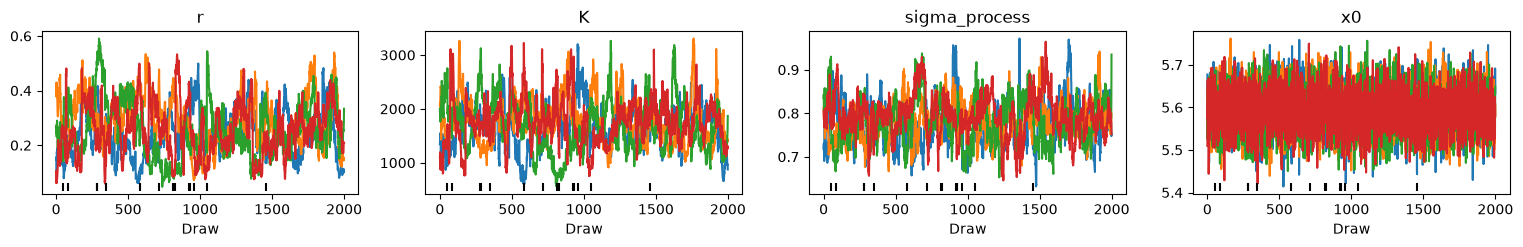

In [47]:
az.plot_trace(trace_v2, var_names=["r","K","sigma_process","x0"])
plt.tight_layout()
plt.show()

In [48]:
n_divergent_lynx = trace_v2.sample_stats.diverging.sum().item()
print(f"Divergences: {n_divergent_lynx}")

Divergences: 14


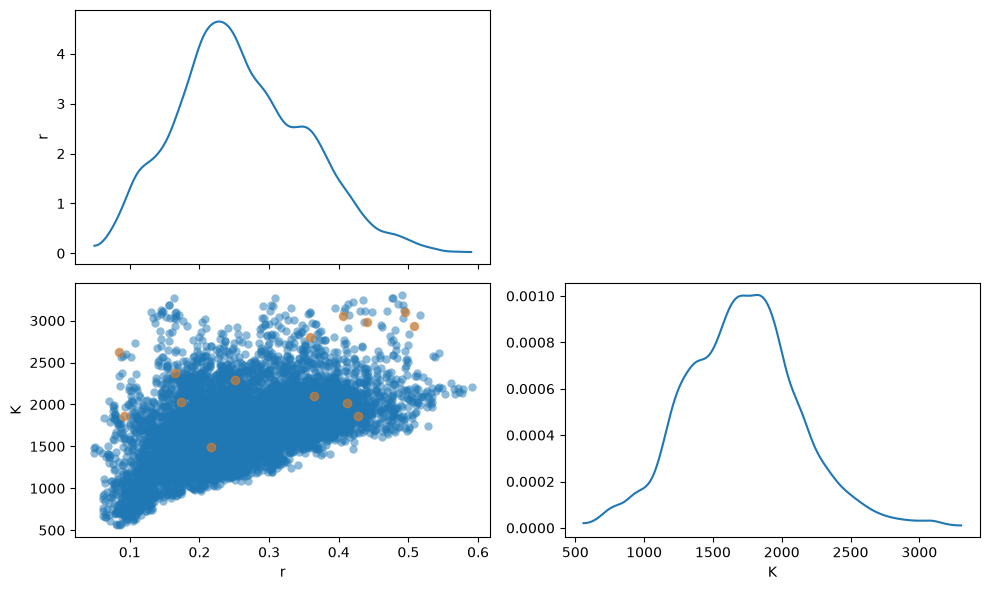

In [49]:
az.plot_pair(trace_v2, var_names=["r", "K"], visuals={"divergence":True}, figure_kwargs={"figsize": (10, 6)})
plt.tight_layout()
plt.show()

In [50]:
#サンプラー強化
with pm.Model() as model_lynx_v2:
    r = pm.TruncatedNormal('r', mu=0.5, sigma=0.5, lower=0)
    
    log_K = pm.Normal('log_K', mu=np.log(count_mean), sigma=0.5)
    K = pm.Deterministic('K', pm.math.exp(log_K))
    
    sigma_process = pm.HalfNormal("sigma_process", sigma=0.5)
    sigma_obs = 0.05
    x0 = pm.Normal("x0", mu=log_count[0], sigma=1)
    innovations = pm.Normal("innovations", mu=0, sigma=1, shape=n-1)

    def step(innov, x_prev, r, K, sigma_process):
        mu_x = x_prev + r * (1 - pm.math.exp(x_prev) / K)
        return mu_x + sigma_process * innov

    x_states, _ = pytensor.scan(
        fn=step,
        sequences=[innovations],
        outputs_info=[x0],
        non_sequences=[r, K, sigma_process]
    )

    x_full = pt.concatenate([[x0], x_states])

    obs = pm.Normal("obs", mu=x_full, sigma=sigma_obs, observed=log_count)

    trace_v2 = pm.sample(
    2000, tune=3000, chains=4,
    target_accept=0.95,
    init="jitter+adapt_diag_grad",
    random_seed=42
)
           
        

/tmp/ipykernel_20668/2013140614.py:17: DeprecationWarning: Scan return signature will change. Updates dict will not be returned, only the first argument. Pass `return_updates=False` to conform to the new API and avoid this warning
  x_states, _ = pytensor.scan(
Initializing NUTS using jitter+adapt_diag_grad...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [r, log_K, sigma_process, x0, innovations]


/home/manaty/markov-regime-switching/.venv/lib/python3.12/site-packages/rich/live.py:260: UserWarning: install 
"ipywidgets" for Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

/home/manaty/markov-regime-switching/.venv/lib/python3.12/site-packages/pymc/step_methods/hmc/quadpotential.py:321: RuntimeWarning: overflow encountered in dot
  return 0.5 * np.dot(x, v_out)
/home/manaty/markov-regime-switching/.venv/lib/python3.12/site-packages/pymc/step_methods/hmc/quadpotential.py:321: RuntimeWarning: overflow encountered in dot
  return 0.5 * np.dot(x, v_out)


Sampling 4 chains for 3_000 tune and 2_000 draw iterations (12_000 + 8_000 draws total) took 92 seconds.
There were 4 divergences after tuning. Increase `target_accept` or reparameterize.
The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details
The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details


In [51]:
az.summary(trace_v2, var_names=["r","K","sigma_process","x0"])

,mean,sd,eti89_lb,eti89_ub,ess_bulk,ess_tail,r_hat,mcse_mean,mcse_sd
r,0.26,0.092,0.11,0.41,229,256,1.01,0.006,0.0041
K,2e+03,5e+02,1100,2500,261,378,1.01,28,26
sigma_process,0.793,0.053,0.72,0.89,196,245,1.02,0.0039,0.0028
x0,5.594,0.0501,5.5,5.7,9681,6553,1.00,0.00051,0.00036


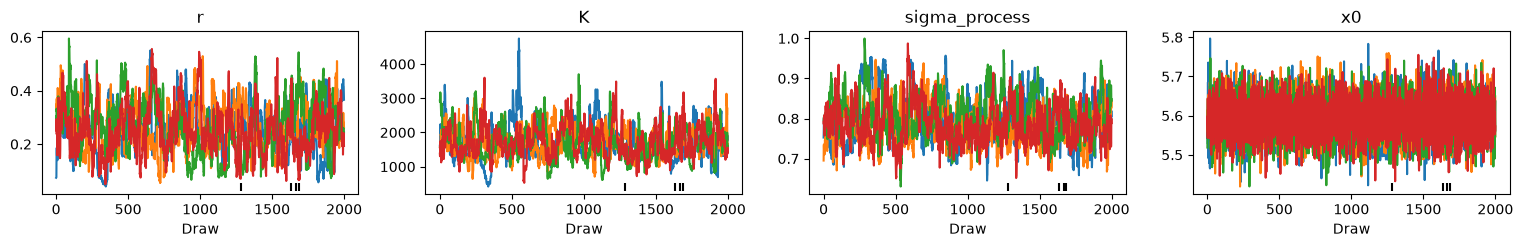

In [52]:
az.plot_trace(trace_v2, var_names=["r","K","sigma_process","x0"])
plt.tight_layout()
plt.show()

In [53]:
n_divergent_lynx = trace_v2.sample_stats.diverging.sum().item()
print(f"Divergences: {n_divergent_lynx}")

Divergences: 4


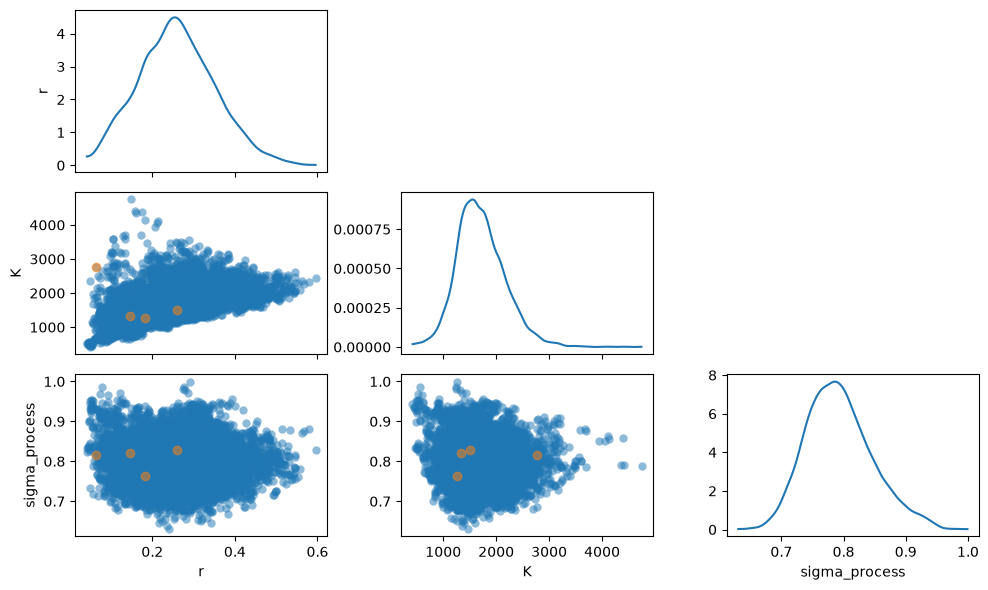

In [54]:
az.plot_pair(trace_v2, var_names=["r", "K", "sigma_process"], visuals={"divergence":True}, figure_kwargs={"figsize": (10, 6)})
plt.tight_layout()
plt.show()

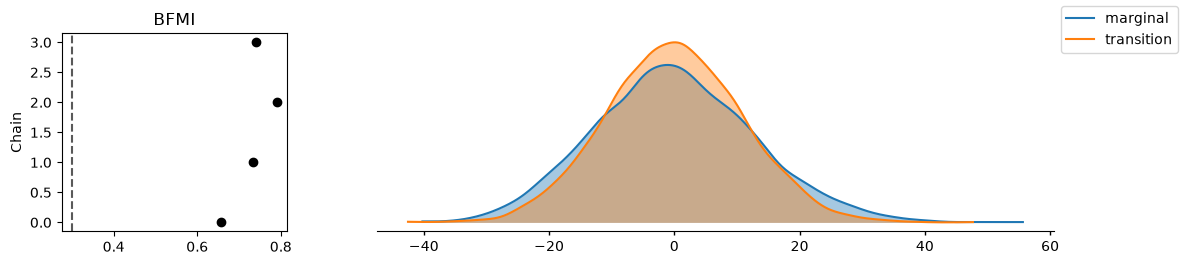

In [55]:
az.plot_energy(trace_v2)

Sampling: [obs, sigma_obs]


/home/manaty/markov-regime-switching/.venv/lib/python3.12/site-packages/rich/live.py:260: UserWarning: install 
"ipywidgets" for Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

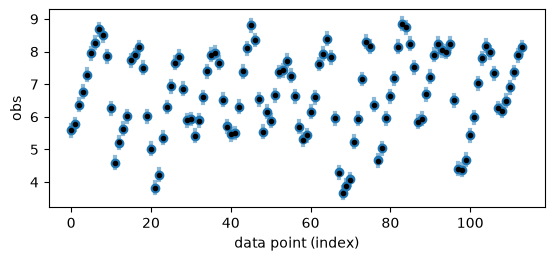

In [60]:
with model_lynx:
    ppc = pm.sample_posterior_predictive(trace_v2)

az.plot_ppc_interval(ppc)

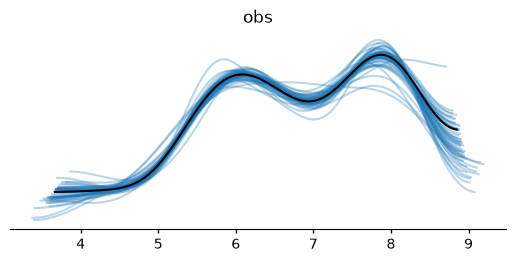

In [61]:
az.plot_ppc_dist(ppc)

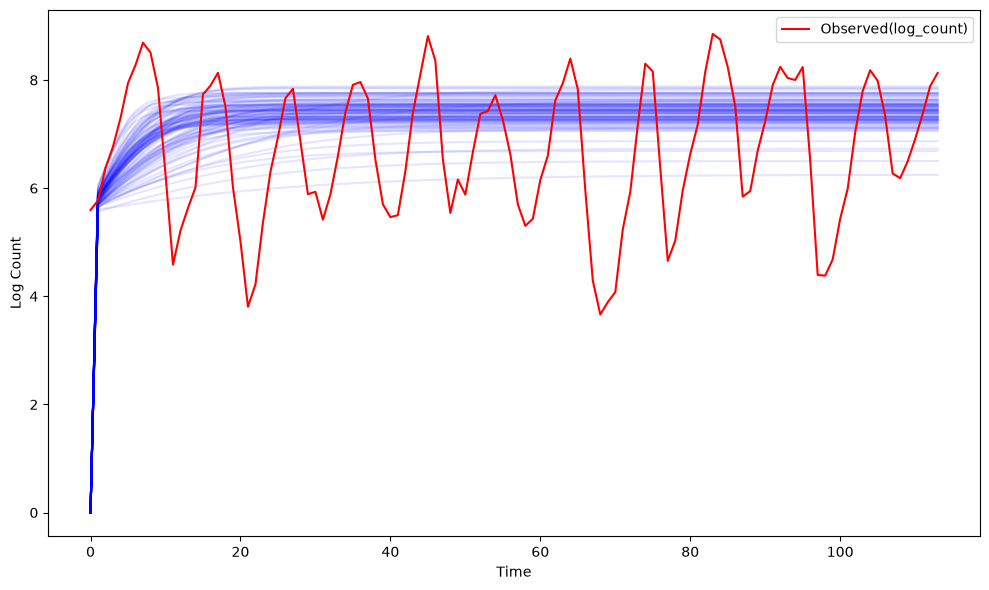

In [67]:
#innovationsを使わずにモデルの予測度を測る
r_samples = trace_v2.posterior["r"].values.reshape(-1)
K_samples = trace_v2.posterior["K"].values.reshape(-1)
x0_samples = trace_v2.posterior["x0"].values.reshape(-1)

n_sim = 100
idx = np.random.choice(len(r_samples), size=n_sim, replace=False)

n_steps = n

trajectiories = np.zeros((n_sim, n_steps))

for i, s in enumerate(idx):
    r_ = r_samples[s]
    K_ = K_samples[s]
    x = x0_samples[s]
    
    for t in range(1, n_steps):
        x = x + r_ * (1 - np.exp(x) / K_)
        trajectiories[i, t] = x

fig, ax = plt.subplots(figsize=(10, 6))
for i in range(n_sim):
    ax.plot(trajectiories[i], color='blue', alpha=0.1)
ax.plot(log_count, color='red', linewidth=1.5, label='Observed(log_count)')
ax.set_xlabel('Time')
ax.set_ylabel('Log Count')
ax.legend()
plt.tight_layout()
plt.show()

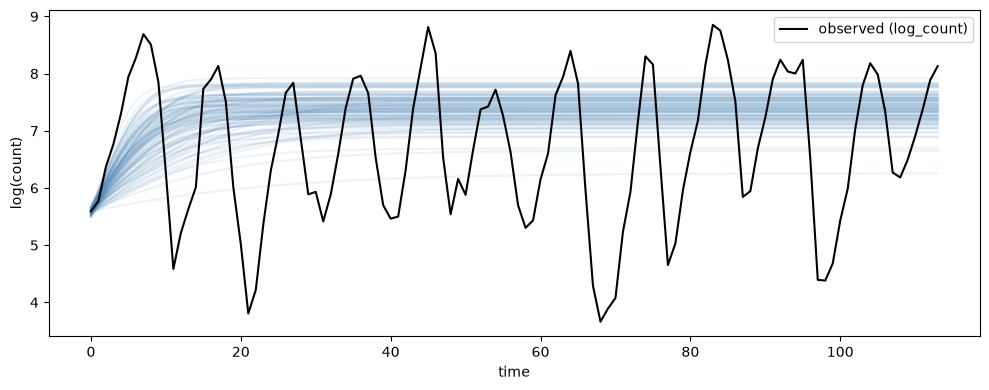

In [66]:
import numpy as np
import matplotlib.pyplot as plt

# 事後サンプルを取り出す(chainとdrawをまとめる)
r_samples = trace_v2.posterior["r"].values.reshape(-1)
K_samples = trace_v2.posterior["K"].values.reshape(-1)
x0_samples = trace_v2.posterior["x0"].values.reshape(-1)

n_sim = 100  # 描画する軌道の本数(全サンプルだと多すぎるので間引く)
idx = np.random.choice(len(r_samples), n_sim, replace=False)

n_steps = n  # 元データと同じ長さ

trajectories = np.zeros((n_sim, n_steps))

for i, s in enumerate(idx):
    r_ = r_samples[s]
    K_ = K_samples[s]
    x = x0_samples[s]
    trajectories[i, 0] = x
    for t in range(1, n_steps):
        x = x + r_ * (1 - np.exp(x) / K_)  # innovationsなし(決定論的)
        trajectories[i, t] = x

# プロット:決定論的な軌道 vs 実データ
fig, ax = plt.subplots(figsize=(10, 4))
for i in range(n_sim):
    ax.plot(trajectories[i], color="steelblue", alpha=0.1)
ax.plot(log_count, color="black", linewidth=1.5, label="observed (log_count)")
ax.set_xlabel("time")
ax.set_ylabel("log(count)")
ax.legend()
plt.tight_layout()
plt.show()

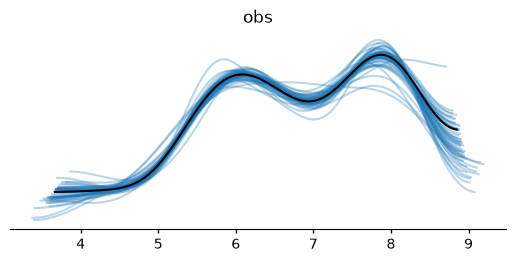

In [68]:
az.plot_ppc_dist(ppc)

# Lynx個体群動態モデリング:非線形状態空間モデルの診断と学び

## 概要

カナダオオヤマネコ(Lynx)の個体数データ(毛皮取引記録)に対して、ロジスティック成長に基づく非線形状態空間モデルをPyMCで構築し、MCMCサンプリングの診断・改善を行った過程の記録。

**モデル構造**:
```
x_t = x_{t-1} + r(1 - exp(x_{t-1})/K) + sigma_process * innovation_t
obs_t ~ Normal(x_t, sigma_obs)
```
- `r`: 内的自然増加率
- `K`: 環境収容力
- `sigma_process`: プロセスノイズ(真の個体群動態の変動)
- `sigma_obs`: 観測ノイズ(記録・測定の誤差)

---

## 1. Divergencesは「目的」ではなく「診断信号」

Divergencesの数を減らすこと自体がゴールではない。本来の目的は「事後分布を偏りなく正しく推定すること」であり、Divergencesはその失敗を知らせる警告に過ぎない。

**必ずセットで確認すべき指標**:
- `r_hat`(目安: ≤ 1.01)
- `ess_bulk` / `ess_tail`(実効サンプルサイズ)
- trace plot のchain間のmixing
- rank plot のチェーン間の一様性

> 見かけ上Divergencesが減っても、r_hatやessが悪化していれば、それは「問題が解決した」のではなく「別の病理(mixing不良)を隠しただけ」の可能性がある。

---

## 2. 事前分布の制約による初期改善

`r`, `K` に `Normal` を使うと理論上負の値も取りうり、`exp(x_prev)/K` が爆発してfunnel(急激な曲率変化)を生む。

**対策**:
- `r`, `K` を正の値に制約(`TruncatedNormal`、または対数スケール化 `log_K = Normal(...)` → `K = exp(log_K)`)

→ 事後分布の解釈しやすさは改善したが、Divergencesの劇的な減少には至らなかった。

---

## 3. sigma_process と sigma_obs の非識別性(Non-identifiability)

`az.summary()` で `sigma_obs` の `r_hat=1.11`、`ess_bulk=35` という明確な赤信号が出現。

**原因**: データの変動が「真の個体数変動(process)」なのか「観測誤差(obs)」なのかを、データだけから区別する情報が不十分。これは日経平均のボラティリティ分析などでも見られる古典的な非識別性の問題と構造的に同じ。

**診断方法**:
- `sigma_process` vs `sigma_obs` の pair plot → divergent pointsが sigma_obs が小さい領域に集中
- trace plotでchainごとの暴れ方を確認
- rank plotでチェーン間の偏りを確認

### 3-1. 強い事前分布による「解決」の罠

`sigma_obs = HalfNormal(sigma=0.1)` のように事前分布を締めると、**むしろr_hatが悪化した(1.11→1.18)**。

**教訓**: 事前分布を締めても事後分布の"形"(病的な曲率)そのものは変わらない。サンプラーに「小さい値を取れ」と圧力をかけることは、funnelの最も狭い領域により長く滞在させることになり逆効果になりうる。

さらに、強い事前分布は「観測誤差は小さい」という仮定を分析者が独断で埋め込むことになり、ドメイン知識による正当化なしに行うのは危険(日経ボラティリティのprocess/obs分解と同じ罠)。

### 3-2. sigma_obs の固定という現実的解決

非識別性が疑われる場合、無理に事前分布で調整するより、**思い切って定数として固定する**方が誠実な場合がある。

```python
sigma_obs_fixed = 0.05
obs = pm.Normal("obs", mu=x_full, sigma=sigma_obs_fixed, observed=log_count)
```

→ Kのess_bulkが27→142に劇的改善、r_hatも1.12→1.01に改善。**非識別性がKの推定を不安定にしていたという仮説が実証された。**

---

## 4. サンプラー設定の強化とそのトレードオフ

### 4-1. target_accept を極端に上げる罠

`target_accept=0.99` にするとDivergencesは155→34に激減したが、**Kのess_bulkが310→27、r_hatが1.00→1.12に悪化**。

**教訓**: ステップサイズを極端に小さくすると、発散はしなくなるが、サンプラーが特定の狭い領域から動けなくなり(stuck)、chain間で異なる場所に閉じ込められる。「発散しない」≠「うまく探索できている」。

### 4-2. 非識別性解消後の段階的なサンプラー強化

sigma_obs固定によって主要な非識別性を解消した**後**であれば、target_accept=0.95・tune増加は健全に機能した:

| 段階 | Divergences | r (r_hat/ess) | K (r_hat/ess) |
|---|---|---|---|
| sigma_obs固定+target_accept=0.9 | 120 | 1.04 / 89 | 1.12 / 27 |
| + target_accept=0.95 | 120 | 1.01 / 229 | 1.01 / 261 |
| + tune増加 | 4 | 1.01 / 229 | 1.01 / 261(推定値は不変) |

**重要な確認ポイント**: サンプラー設定を変えても**推定値(mean, sd, ess)がほぼ変わらない**ことを確認できた。これは事後分布がサンプラー設定に対して頑健であることを意味し、残っていた少数のDivergencesが深刻な病理ではなかったことの裏付けとなる。

### 4-3. Divergent pointsの分布パターンで病理の種類を切り分ける

- **局所集中型**(特定の隅・境界に集中)→ モデルの構造的な非識別性・funnelを示唆
- **分散型**(事後分布の主要な塊全体に薄く散らばる)→ 単にステップサイズがギリギリ足りていないだけの可能性が高く、tune増加等で解消しやすい

---

## 5. Posterior Predictive Check(PPC)だけでは不十分な理由

`az.plot_ppc_interval` / `plot_ppc_dist` の結果は良好(観測値が予測区間に収まる、分布形状も一致)だった。しかし、これは**モデルの構造(r, K)が現象を説明できていることの証明にはならない**。

**理由**: 状態空間モデルの `innovations`(process noise)は各時点で自由に調整可能なため、たとえロジスティック成長の部分が何も説明していなくても、process noiseが観測値に「帳尻合わせ」して良好なPPCを作れてしまう。

### 5-1. 検証方法:Process noiseなしのForward Simulation

`r`, `K`, `x0` の事後サンプルのみを使い、innovationsを使わず決定論的にモデルを走らせる:

```python
for t in range(1, n_steps):
    x = x + r_ * (1 - np.exp(x) / K_)  # innovationsなし
```

**結果**: シミュレートされた軌道は序盤で急上昇した後、K付近で完全に平坦化。実データに見られる10年周期の激しい振動は一切再現されなかった。

**結論**: 観測データの周期性は、モデル構造(ロジスティック成長)由来ではなく、ほぼ全てprocess noise側が「帳尻合わせ」として生成していたものだった。

---

## 6. 最終的な結論:単変量モデルの限界

単純なロジスティック成長モデル(1種の個体群のみを扱う)は、**捕食者-被食者相互作用に起因する周期振動を原理的に説明できない**。これは実データ(Lynxの毛皮取引記録)が実際に持つ約10年周期の変動と、モデルが持つ機構(単調にKへ収束するだけ)との間の本質的なミスマッチである。

サンプリングの技術的問題(非識別性、funnel、mixing不良)をすべて解消した上でこの限界を実証できたことで、「モデルが悪いのか、サンプリングが悪いのか」を明確に切り分けることができた。

### 得られた点推定(参考値)
- r ≈ 0.26 (内的自然増加率)
- K ≈ 2000 (環境収容力)
- sigma_process ≈ 0.79

これらの値自体はPPC上で観測データの分布と整合しており、一定の妥当性はあるが、**時系列としての動態(周期性)は説明できていない**。

### 今後の発展方向(課題として)
- Hare(ノウサギ)データを用いたLotka-Volterra型の捕食者-被食者モデルへの拡張
- sin/cos項などによる周期性の明示的な組み込み

---

## 診断プロセスのフローまとめ

```
初期モデル(Divergences多数)
    │
    ├─ r, Kを正値制約・対数化 → 部分的改善
    │
    ├─ az.summary()でsigma_obsのr_hat異常を発見
    │   └─ pair plot / trace plot / rank plotで非識別性を確認
    │
    ├─ 強い事前分布を試す → 悪化(funnelの罠)
    │
    ├─ sigma_obsを固定 → Kの収束が劇的改善
    │
    ├─ target_accept/tuneを段階的に強化
    │   └─ 推定値の安定性を確認しながら調整
    │
    ├─ Divergences ほぼ解消、r_hat/ess良好
    │
    ├─ PPC確認 → 見た目は良好(ただし要注意)
    │
    └─ Process noiseなしのforward simulationで検証
        └─ モデル構造の限界(周期性を説明できない)を実証
```

## 汎用的な教訓(他のモデリングにも応用可能)

1. **Divergencesは症状であって病気ではない** — 常にr_hat/essとセットで見る
2. **事前分布で無理やり収束させると、結果に分析者の仮定を埋め込んでしまうリスクがある** — ドメイン知識で正当化するか、感度分析を行う
3. **サンプラー設定(target_accept等)を変えたときは、推定値自体が変わっていないか必ず確認する** — 変わっていれば「見せかけの改善」の可能性
4. **PPCが良好でも、モデルの機構が現象を説明しているとは限らない** — 特に潜在変数(process noise)が自由度を持つモデルでは、機構による説明と自由度による帳尻合わせを区別する検証が必要
5. **サンプリングの技術的問題とモデルの構造的限界は、切り分けて評価する** — 前者を解決して初めて、後者を正しく評価できる
